<a href="https://colab.research.google.com/github/abudofa2017-lgtm/Pharmacovigilance-data-practice-/blob/main/Logistic_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Abasiama Udofa - SCA/APC3/DS/064**

In [21]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

In [22]:
#Loading the dataset
diabetes_df = pd.read_csv('diabetes_clean.csv')

In [23]:
#Displaying the first few rows to understand the dataset
print("First few rows of the dataset:")
print(diabetes_df.head())

First few rows of the dataset:
   pregnancies  glucose  diastolic  triceps  insulin   bmi    dpf  age  \
0            6      148         72       35        0  33.6  0.627   50   
1            1       85         66       29        0  26.6  0.351   31   
2            8      183         64        0        0  23.3  0.672   32   
3            1       89         66       23       94  28.1  0.167   21   
4            0      137         40       35      168  43.1  2.288   33   

   diabetes  
0         1  
1         0  
2         1  
3         0  
4         1  


In [24]:
#Checking for missing vales
print("Missing values in the dataset:")
print(diabetes_df.isnull().sum())

Missing values in the dataset:
pregnancies    0
glucose        0
diastolic      0
triceps        0
insulin        0
bmi            0
dpf            0
age            0
diabetes       0
dtype: int64


In [25]:
# Printing all column names to confirm
print("Column names:", diabetes_df.columns.tolist())

Column names: ['pregnancies', 'glucose', 'diastolic', 'triceps', 'insulin', 'bmi', 'dpf', 'age', 'diabetes']


**Creating Feature Array and Target Array**

In [26]:
#Creating seperate feature array (X) and target array (y)
target_col = 'diabetes'
X = diabetes_df.drop(target_col, axis=1)
y = diabetes_df[target_col]

print ("Feature array (X) shape:", X.shape)
print ("Target array (y) shape:", y.shape)
print("First 10 target values:", y.head(10))

Feature array (X) shape: (768, 8)
Target array (y) shape: (768,)
First 10 target values: 0    1
1    0
2    1
3    0
4    1
5    0
6    1
7    0
8    1
9    1
Name: diabetes, dtype: int64


**Splitting the Data into Training and Test Sets**

In [27]:
#Splitting into training and test sets (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Training class distribution:", y_train.value_counts())


Training set size: 537
Test set size: 231
Training class distribution: diabetes
0    349
1    188
Name: count, dtype: int64


**Instantiating and Training the logistic regression model**


In [28]:
#Creating a LogisticRegresssion object and assigning to variable "logreg"
logreg = LogisticRegression(random_state=42)  #the random state ensures reproducible results

#Fitting the model into the training data
logreg.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

**Predicting probabilities for the test set**

In [29]:
#Using the trained model to predict probabilities for the test set
#predict_proba() returns a 2D array: [probability of class 0, probability of class 1]
#we want the probability of class 1 (diabetes diagnosis), so we take all rows and column index 1

y_pred_probs = logreg.predict_proba(X_test)[:, 1]

#Displaying  prediced probabilities to check
print("predicted probabilities of diabetes:")
print(y_pred_probs[:])

First 10 predicted probabilities of diabetes:
[0.26551023 0.1833662  0.12119647 0.15613529 0.496112   0.44582199
 0.01359246 0.61646099 0.55640532 0.79311794 0.22811271 0.90039045
 0.38441599 0.28562141 0.069536   0.35980759 0.12715512 0.06866351
 0.8586792  0.59358232 0.21195404 0.07553857 0.47013264 0.09345246
 0.54357544 0.88643666 0.10829573 0.03023439 0.27293001 0.11402146
 0.91422211 0.8805986  0.80553739 0.82376654 0.63936853 0.685457
 0.95479798 0.22859257 0.48080729 0.7295972  0.06276096 0.58338156
 0.55426578 0.31526812 0.0283223  0.52928546 0.60828927 0.20559607
 0.33659492 0.96396598 0.04401614 0.65924584 0.82521793 0.25868064
 0.10735579 0.0373765  0.79004143 0.00409037 0.4040023  0.77799103
 0.72446664 0.34511163 0.22945724 0.20603459 0.08196644 0.61797186
 0.04483287 0.78383891 0.03681329 0.78916956 0.69558142 0.06639789
 0.16847442 0.11906742 0.08949262 0.5057417  0.16008386 0.11517187
 0.1387362  0.26308572 0.66970414 0.13651337 0.05571403 0.40472381
 0.26578906 0.8647

**Scatter Plot: Predicted Probability vs. Index (ordered by prediction)**

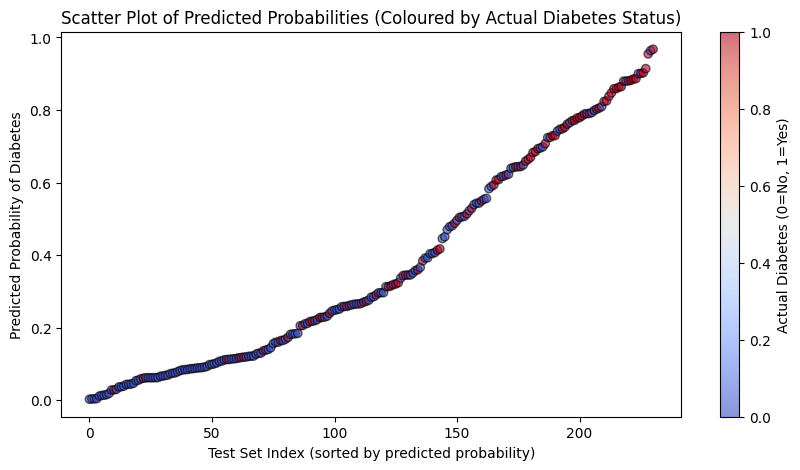

In [30]:
#Plotting the predicted probability versus the Index
# Sort by predicted probability for a cleaner trend
sorted_indices = np.argsort(y_pred_probs)
sorted_probs = y_pred_probs[sorted_indices]
sorted_actual = y_test.values[sorted_indices]

plt.figure(figsize=(10, 5))
plt.scatter(range(len(sorted_probs)), sorted_probs, c=sorted_actual, cmap='coolwarm', alpha=0.6, edgecolors='k')
plt.xlabel('Test Set Index (sorted by predicted probability)')
plt.ylabel('Predicted Probability of Diabetes')
plt.title('Scatter Plot of Predicted Probabilities (Coloured by Actual Diabetes Status)')
plt.colorbar(label='Actual Diabetes (0=No, 1=Yes)')
plt.show()

**Quick performance check**

In [31]:
"""
The scatter plot sorts test set individuals by their predicted probability of diabetes (lowest to highest, left to right).
Each point's colour shows actual diabetes status (blue = No, red = Yes, according to the colour bar).

Interpretation:
- On the left side (low predicted probabilities), most points are blue (actual No diabetes). This is correct.
- On the right side (high predicted probabilities), most points are red (actual Yes diabetes). This is also correct.
- However, there are some red points mixed in the left region (false negatives: actual Yes but predicted low probability).
- Similarly, some blue points appear on the right (false positives: actual No but predicted high probability).

Overall, the diagonal colour gradient from blue to red indicates the model separates the two classes reasonably well,
but not perfectly. This is supported by the performance metrics:
- Accuracy = 0.7403 (74% correct predictions)
- ROC-AUC = 0.8002 (good discrimination ability, well above random guessing 0.5)
The model is useful but has room for improvement (e.g., more features or tuning).
"""

"\nThe scatter plot sorts test set individuals by their predicted probability of diabetes (lowest to highest, left to right).\nEach point's colour shows actual diabetes status (blue = No, red = Yes, according to the colour bar).\n\nInterpretation:\n- On the left side (low predicted probabilities), most points are blue (actual No diabetes). This is correct.\n- On the right side (high predicted probabilities), most points are red (actual Yes diabetes). This is also correct.\n- However, there are some red points mixed in the left region (false negatives: actual Yes but predicted low probability).\n- Similarly, some blue points appear on the right (false positives: actual No but predicted high probability).\n\nOverall, the diagonal colour gradient from blue to red indicates the model separates the two classes reasonably well,\nbut not perfectly. This is supported by the performance metrics:\n- Accuracy = 0.7403 (74% correct predictions)\n- ROC-AUC = 0.8002 (good discrimination ability, wel

In [32]:
# Calculating accuracy and ROC‑AUC to ensure the model is meaningful
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_probs)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC: {roc_auc:.4f}")

Test Accuracy: 0.7403
Test ROC-AUC: 0.8002
